# Yield Curve PCA

Fits PCA factors (level, slope, curvature) to historical Treasury par yield curve
changes, reading directly from Postgres via DuckDB's `postgres` extension --
no separate fetch/parse step, the history already lives in the canonical store
populated by [DailyTreasuryParYieldCurve.ipynb](../YieldCurve/DailyTreasuryParYieldCurve.ipynb).

See [docs/refactor-plan.md](../docs/refactor-plan.md) section 8 for the design.

## Load history via DuckDB -> Postgres

In [1]:
from fred_lx.storage.duckdb_store import attach_postgres
from fred_lx.analysis.pca import fit_yield_pca
from fred_lx.viz.pca import plot_components, plot_explained_variance, plot_scores

# YAGNI note: this is a plain SELECT, no pivot/window functions, so today
# it's equivalent to postgres_store.read_curve_history() via psycopg. Kept
# on DuckDB as a bet that SQL-side analytics (rolling stats, joins) show up
# later -- revisit if that bet doesn't pay off.
con = attach_postgres()
history = con.sql("""
    SELECT curve_date AS date, maturity_years, par_yield
    FROM pg.treasury_par_yields
    WHERE source = 'treasury_xml'
""").df()

print(f"{len(history):,} rows, {history['date'].nunique()} dates, "
      f"{history['date'].min()} -> {history['date'].max()}")
history.head()

4,758 rows, 366 dates, 2025-01-02 00:00:00 -> 2026-06-18 00:00:00


,date,maturity_years,par_yield
0,2025-01-02,0.083333,4.45
1,2025-01-03,0.083333,4.44
2,2025-01-06,0.083333,4.43
3,2025-01-07,0.083333,4.42
4,2025-01-08,0.083333,4.41


## Fit PCA on day-over-day yield changes

In [2]:
# c_start sets the number of initial columns to drop from the yield curve data before fitting PCA. 
# This can be useful if you want to exclude very short maturities from the analysis.
result = fit_yield_pca(history, n_components=4, c_start=5)

for i, ratio in enumerate(result.explained_variance_ratio, start=1):
    print(f"PC{i}: {ratio:.1%} of variance")

PC1: 86.1% of variance
PC2: 10.5% of variance
PC3: 1.4% of variance
PC4: 0.9% of variance


## Component shapes (level / slope / curvature)

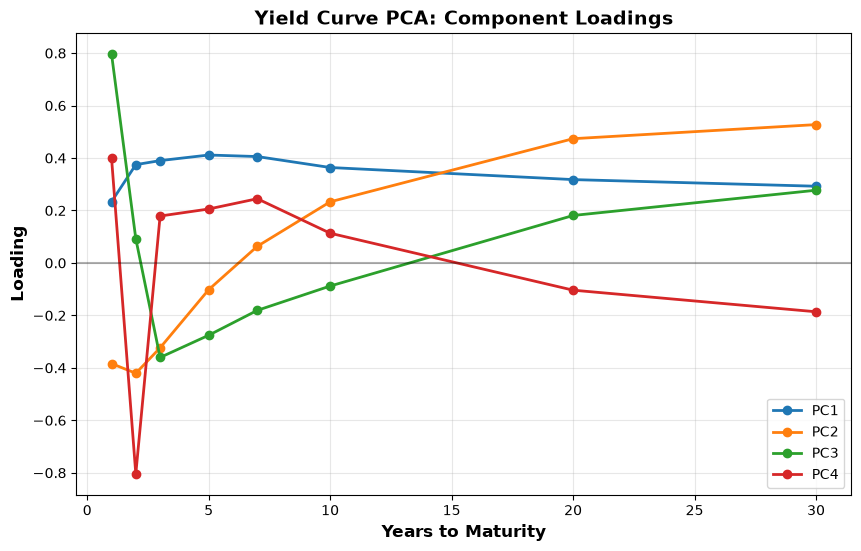

In [3]:
plot_components(result);

In [6]:
print(result.maturities)

[ 1.  2.  3.  5.  7. 10. 20. 30.]


In [7]:
print(result.explained_variance_ratio)

[0.86138474 0.10542854 0.01386851 0.00866893]


In [8]:
print(result.variance_table)

                total_explained_pct        PC1        PC2        PC3       PC4
maturity_years                                                                
1.0                       99.996557  64.608183  21.341020  12.128948  1.921849
2.0                       99.920346  83.231951  12.831851   0.081375  3.854823
3.0                       98.034968  90.908846   7.650848   1.248009  0.192297
5.0                       98.687293  98.305403   0.737003   0.710441  0.247153
7.0                       98.815646  99.024312   0.295792   0.316709  0.363187
10.0                      98.822628  95.045205   4.772429   0.089510  0.092856
20.0                      98.873388  78.232372  21.275162   0.408503  0.083963
30.0                      98.812958  70.597091  28.094185   1.021118  0.287605
